## Первоначальный анализ датасета

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn


In [92]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(1460, 81)
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [93]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [94]:
train_df.isna().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

### Мини-вывод

- У нас 81 признак. У некоторых признаков большое количество пропущенных значений. Но это не значит что-то плохое, что до конца недозаполнили данные. Пропуски могут иметь смысл, например PoolQC показывает есть ли бассейн у дома, если его нет, то соответственно значение пропущено. Другие признаки также стоит разобрать и понять, чтобы попросту не удалять просто так признак или заполнять пропуски каким-либо образом

In [95]:
train_df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

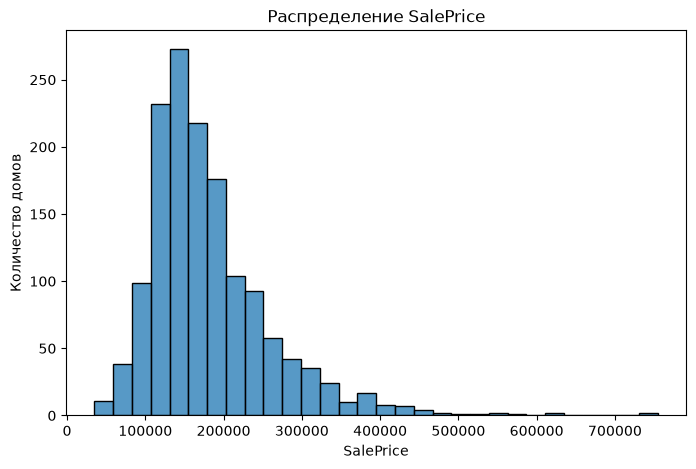

In [96]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df["SalePrice"], bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Количество домов")
plt.title("Распределение SalePrice")
plt.show()

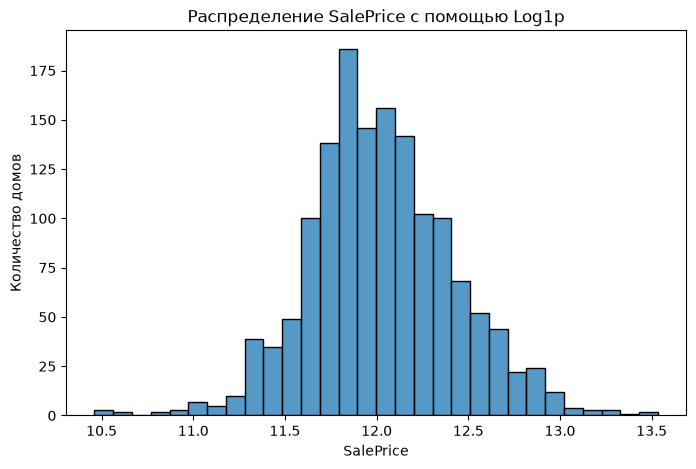

In [97]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(train_df["SalePrice"]), bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Количество домов")
plt.title("Распределение SalePrice с помощью Log1p")
plt.show()

### Мини-вывод

- Обычный SalePrice сильно скошен вправо
- log1p(SalePrice) заметно похож на нормальное распределение
- Обучать будем на логарифме целевой переменной, чтобы большие ценники домов не так сильно влияли на решение модели

In [98]:
numeric_features = train_df.select_dtypes(include=["int64", "float64"]).columns
categorical_features = train_df.select_dtypes(include=["object", "str"]).columns

print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

Числовых признаков: 38
Категориальных признаков: 43


In [99]:
correlations = (
    train_df[numeric_features]
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

correlations.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

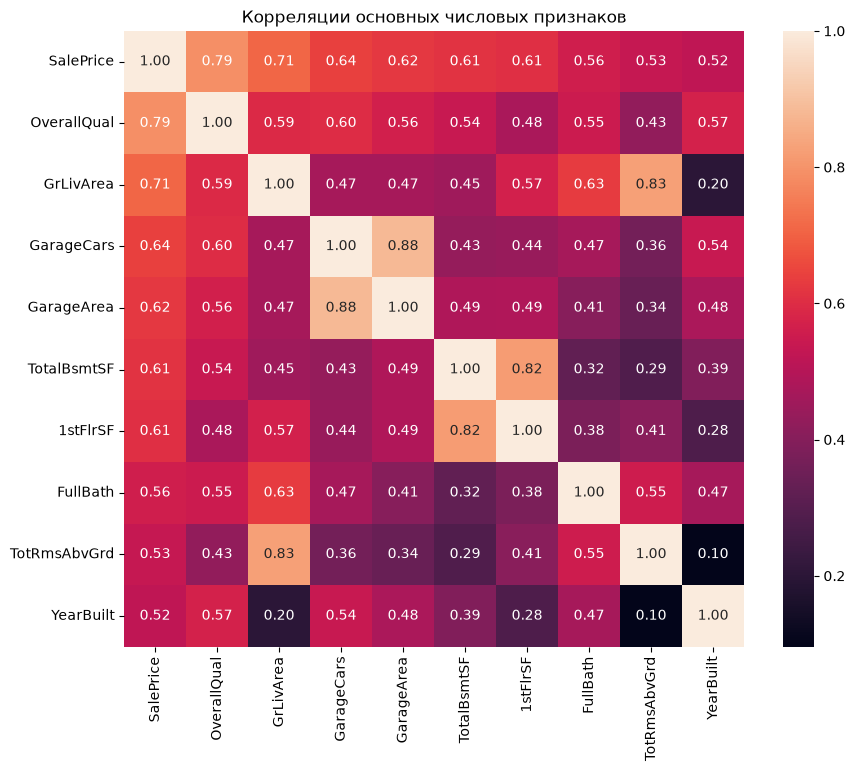

In [100]:
top_features = correlations.head(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    train_df[top_features].corr(),
    annot=True,
    fmt=".2f")

plt.title("Корреляции основных числовых признаков")
plt.show()

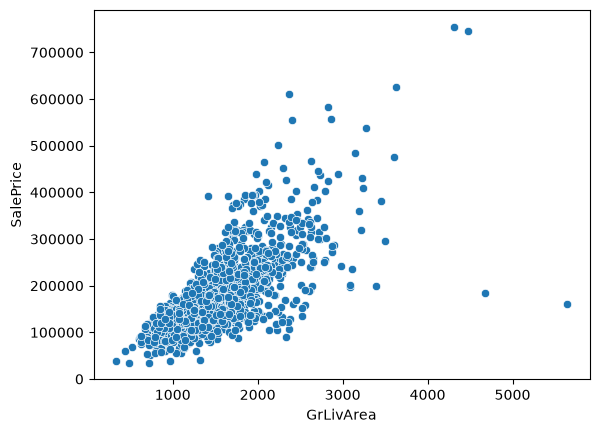

In [101]:
sns.scatterplot(train_df, x="GrLivArea", y="SalePrice")
plt.show()

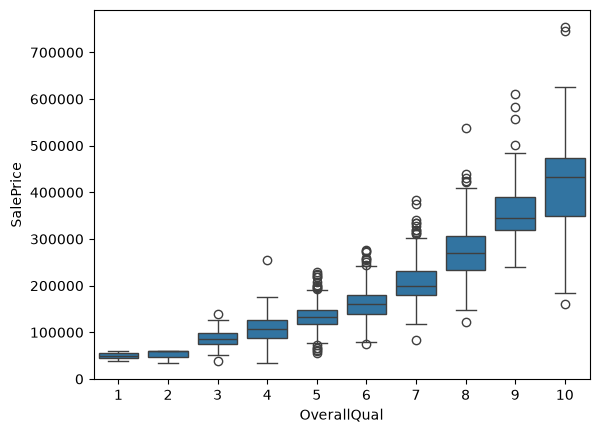

In [102]:
sns.boxplot(
    data=train_df,
    x="OverallQual",
    y="SalePrice"
)
plt.show()

### Мини-вывод
- OverallQual сильнее всего связан с SalePrice — корреляция около 0.79. GrLivArea тоже очень сильный признак — около 0.71. Ещё заметны GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, YearBuilt
- Также видна корреляция между самими признаками — GarageCars и GarageArea ≈ 0.88, GrLivArea и TotRmsAbvGrd ≈ 0.83, TotalBsmtSF и 1stFlrSF ≈ 0.82. Признаки дублируют информацию друг друга, это может быть критично для линейных моделей
- На scatterplot GrLivArea и SalePrice хорошо виден общий тренд: чем больше жилая площадь, тем выше цена. Также справа видны скорее всего выбросы, пару домов с большой площадью и низкой ценой
- Boxplot OverallQual показывает почти монотонную зависимость: чем выше качество дома, тем выше медианная цена

In [103]:
categorical_summary = pd.DataFrame({
    "n_unique": train_df[categorical_features].nunique(),
    "missing": train_df[categorical_features].isna().sum()
}).sort_values("n_unique")

categorical_summary

,n_unique,missing
Street,2,0
Alley,2,1369
Utilities,2,0
CentralAir,2,0
MasVnrType,3,872
LandSlope,3,0
PavedDrive,3,0
GarageFinish,3,81
PoolQC,3,1453
ExterQual,4,0


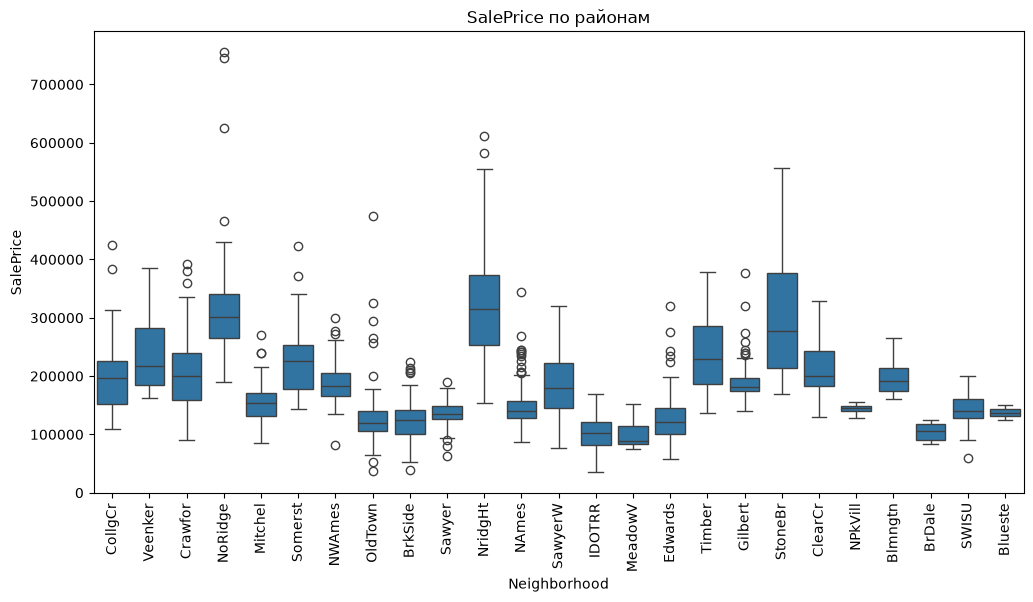

In [104]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train_df,
    x="Neighborhood",
    y="SalePrice"
)
plt.xticks(rotation=90)
plt.title("SalePrice по районам")
plt.show()

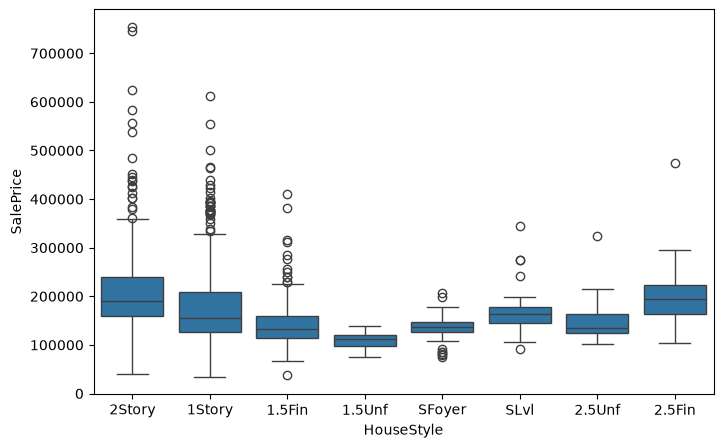

In [105]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=train_df,
    x="HouseStyle",
    y="SalePrice"
)
plt.show()

In [106]:
train_df.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False)

Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
CollgCr    197200.0
Blmngtn    191000.0
NWAmes     182900.0
Gilbert    181000.0
SawyerW    179900.0
Mitchel    153500.0
NPkVill    146000.0
NAmes      140000.0
SWISU      139500.0
Blueste    137500.0
Sawyer     135000.0
BrkSide    124300.0
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64

### Мини-выводы

- По Neighborhood видно, что район реально сильно влияет на цену: медианы заметно различаются. Например, NridgHt, NoRidge, StoneBr заметно дороже, а MeadowV, IDOTRR, BrDale дешевле
- HouseStyle тоже влияет на цену, но слабее и менее однозначно. Там есть группы с разным разбросом и количеством выбросов
- Таблица categorical_summary тоже полезная: она показывает, где мало категорий, а где много пропусков. Опять же где-то пропуски являются важными состоявляющими признака

In [107]:
missing_percent = (
    train_df.isna().mean() * 100
).sort_values(ascending=False)

missing_percent.head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

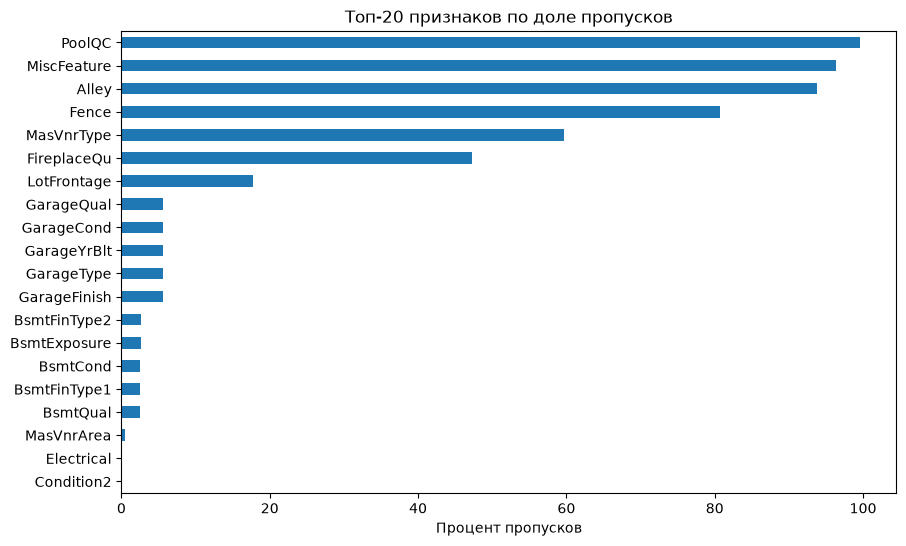

In [108]:
plt.figure(figsize=(10, 6))
missing_percent.head(20).sort_values().plot(kind="barh")
plt.xlabel("Процент пропусков")
plt.title("Топ-20 признаков по доле пропусков")
plt.show()

In [109]:
train_df[
    ["GrLivArea", "SalePrice"]
].sort_values("GrLivArea", ascending=False).head(10)

,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750
1182,4476,745000
691,4316,755000
1169,3627,625000
185,3608,475000
304,3493,295000
1268,3447,381000
635,3395,200000
769,3279,538000


In [110]:
train_df[
    (train_df["GrLivArea"] > 4000) &
    (train_df["SalePrice"] < 300000)
][["Id", "GrLivArea", "SalePrice"]]

,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


### Мини-вывод

- По пропускам видно две группы:
1) почти полностью пустые признаки: PoolQC, MiscFeature, Alley, Fence
2) признаки с умеренным количеством пропусков: LotFrontage, гаражные признаки, basement-признаки, MasVnrArea, Electrical

- Нашли два подозрительныйх выброса с id 524 и id 1299
- Какие-то пустые значения заполним, какие-то оставим пустыми

## Preprocessing и baseline-модель

### Preprocessing

In [111]:
X = train_df.drop(columns=["SalePrice", "Id"])
y = np.log1p(train_df["SalePrice"])

In [112]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "str"]).columns

print("Числовых:", len(numeric_features))
print("Категориальных:", len(categorical_features))

Числовых: 36
Категориальных: 43


In [113]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### Linear Regression

In [114]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(baseline_model, X, y, cv=cv, scoring="neg_root_mean_squared_error")

rmse_scores = -scores

print("RMSE по фолдам:", rmse_scores)
print("Средний RMSE:", rmse_scores.mean())
print("Std:", rmse_scores.std())

RMSE по фолдам: [0.12808613 0.12463035 0.24265082 0.15519602 0.11315305]
Средний RMSE: 0.1527432743095968
Std: 0.0470214435017469


### Ridge

In [115]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_scores = cross_val_score(ridge_model, X, y, cv=cv, scoring="neg_root_mean_squared_error")

ridge_rmse = -ridge_scores

print("Ridge RMSE по фолдам:", ridge_rmse)
print("Средний Ridge RMSE:", ridge_rmse.mean())
print("Std:", ridge_rmse.std())

Ridge RMSE по фолдам: [0.13162288 0.12894326 0.2293616  0.13414537 0.11895472]
Средний Ridge RMSE: 0.14860556589236817
Std: 0.04070583598878296


In [116]:
for alpha in [0.01, 0.1, 1, 10, 100]:
   ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=alpha))
    ])
   
   ridge_scores = cross_val_score(ridge_model, X, y, cv=cv, scoring="neg_root_mean_squared_error")
   ridge_rmse = -ridge_scores

   print(
        f"alpha={alpha:<6} "
        f"mean={ridge_rmse.mean():.5f} "
        f"std={ridge_rmse.std():.5f}"
    )

alpha=0.01   mean=0.15224 std=0.04689
alpha=0.1    mean=0.15073 std=0.04557
alpha=1      mean=0.14861 std=0.04071
alpha=10     mean=0.14678 std=0.03933
alpha=100    mean=0.14724 std=0.03929


- Лучший alpha для Ridge равен 10

### Lasso

In [117]:
for alpha in [0.0001, 0.001, 0.01, 0.1, 1]:
   lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=alpha, max_iter=10000))
    ])
   
   lasso_scores = cross_val_score(lasso_model, X, y, cv=cv, scoring="neg_root_mean_squared_error")
   lasso_rmse = -lasso_scores

   print(
        f"alpha={alpha:<6} "
        f"mean={lasso_rmse.mean():.5f} "
        f"std={lasso_rmse.std():.5f}"
    )

alpha=0.0001 mean=0.14481 std=0.04534
alpha=0.001  mean=0.14428 std=0.04247
alpha=0.01   mean=0.15977 std=0.03943
alpha=0.1    mean=0.22284 std=0.01623
alpha=1      mean=0.39878 std=0.02513


- Лучший alpha для Lasso равен 0.001 

### Elastic Net

In [118]:
best_elasitc_rmse = float("inf")
best_elastic_params = None

for alpha in [0.0001, 0.001, 0.01, 0.1]:
    for l1_ratio in [0.2, 0.5, 0.8]:
        elastic_model = Pipeline([
            ("preprocessor", preprocessor),
            ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000))
        ])

        elastic_scores = cross_val_score(elastic_model, X, y, cv=cv, scoring="neg_root_mean_squared_error")

        elastic_rmse = -elastic_scores
        mean_elastic_rmse = elastic_rmse.mean()
        elastic_std_rmse = elastic_rmse.std()

        print(
            f"alpha={alpha:<7} "
            f"l1_ratio={l1_ratio:<4} "
            f"mean={mean_elastic_rmse:.5f} "
            f"std={elastic_std_rmse:.5f}"
        )

        if mean_elastic_rmse < best_elasitc_rmse:
            best_elasitc_rmse = mean_elastic_rmse
            best_elastic_params = {
                "alpha": alpha,
                "l1_ratio": l1_ratio
            }

print("\nЛучшие параметры:")
print(best_elastic_params)
print(f"Лучший RMSE: {best_elasitc_rmse:.5f}")

alpha=0.0001  l1_ratio=0.2  mean=0.14835 std=0.04497
alpha=0.0001  l1_ratio=0.5  mean=0.14604 std=0.04488
alpha=0.0001  l1_ratio=0.8  mean=0.14509 std=0.04535
alpha=0.001   l1_ratio=0.2  mean=0.14466 std=0.04043
alpha=0.001   l1_ratio=0.5  mean=0.14285 std=0.04202
alpha=0.001   l1_ratio=0.8  mean=0.14352 std=0.04244
alpha=0.01    l1_ratio=0.2  mean=0.15019 std=0.04152
alpha=0.01    l1_ratio=0.5  mean=0.15565 std=0.04074
alpha=0.01    l1_ratio=0.8  mean=0.15829 std=0.03979
alpha=0.1     l1_ratio=0.2  mean=0.16612 std=0.03232
alpha=0.1     l1_ratio=0.5  mean=0.18675 std=0.02161
alpha=0.1     l1_ratio=0.8  mean=0.20756 std=0.01654

Лучшие параметры:
{'alpha': 0.001, 'l1_ratio': 0.5}
Лучший RMSE: 0.14285


In [119]:
results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "CV RMSE": rmse_scores.mean(),
        "CV Std": rmse_scores.std()
    },
    {
        "Model": "Ridge",
        "CV RMSE": 0.14678,
        "CV Std": 0.03933
    },
    {
        "Model": "Lasso",
        "CV RMSE": 0.14428,
        "CV Std": 0.04247
    },
    {
        "Model": "ElasticNet",
        "CV RMSE": 0.14285,
        "CV Std": 0.04202
    }
])

results = results.sort_values("CV RMSE").reset_index(drop=True)

results

,Model,CV RMSE,CV Std
0,ElasticNet,0.142850,0.042020
1,Lasso,0.144280,0.042470
2,Ridge,0.146780,0.039330
3,Linear Regression,0.152743,0.047021


In [120]:
results.to_csv("../reports/results.csv", index=False)

### Мини-вывод

- Ridge Regression — лучший результат при alpha=10: RMSE = 0.14678
- Lasso Regression — лучший результат при alpha=0.001: RMSE = 0.14428
- ElasticNet — лучший результат при alpha=0.001 и l1_ratio=0.5: RMSE = 0.14285

Лучший результат среди протестированных линейных моделей показал ElasticNet.
По сравнению с обычной Linear Regression (RMSE = 0.15274) регуляризация улучшила качество модели. Lasso и ElasticNet также способны уменьшать влияние менее полезных признаков за счёт L1-регуляризации

## Decision Tree

In [121]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(
        random_state=42
    ))
])

tree_parameters = {
    "regressor__max_depth": [3, 5, 7, 10, 15, 20, None],
    "regressor__min_samples_split": [2, 5, 10, 20],
    "regressor__min_samples_leaf": [1, 2, 4, 8],
    "regressor__max_features": [None, "sqrt", "log2", 0.5, 0.8],
    "regressor__criterion": [
    "squared_error",
    "absolute_error"
    ]
}

tree_search = RandomizedSearchCV(
    estimator=tree_model,
    param_distributions=tree_parameters,
    n_iter=40,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

tree_search.fit(X, y)

tree_best_index = tree_search.best_index_

tree_rmse = -tree_search.best_score_
tree_std = tree_search.cv_results_["std_test_score"][tree_best_index]

print("Лучшие параметры:")
print(tree_search.best_params_)

print("Лучший CV RMSE:")
print(tree_rmse)

print("CV Std:")
print(tree_std)

results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "Decision Tree",
        "CV RMSE": tree_rmse,
        "CV Std": tree_std
    }])
], ignore_index=True)

results = results.sort_values("CV RMSE").reset_index(drop=True)

Лучшие параметры:
{'regressor__min_samples_split': 10, 'regressor__min_samples_leaf': 2, 'regressor__max_features': None, 'regressor__max_depth': 7, 'regressor__criterion': 'absolute_error'}
Лучший CV RMSE:
0.19017408104710762
CV Std:
0.012150645303660406


In [122]:
results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results

,Model,CV RMSE,CV Std
0,ElasticNet,0.142850,0.042020
1,Lasso,0.144280,0.042470
2,Ridge,0.146780,0.039330
3,Linear Regression,0.152743,0.047021
4,Decision Tree,0.190174,0.012151


## Random Forest

In [123]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_parameters = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__max_depth": [5, 10, 15, 20, None],
    "regressor__min_samples_split": [2, 5, 10, 20],
    "regressor__min_samples_leaf": [1, 2, 4, 8],
    "regressor__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    "regressor__bootstrap": [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_parameters,
    n_iter=40,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

rf_search.fit(X, y)

rf_best_index = rf_search.best_index_

rf_rmse = -rf_search.best_score_
rf_std = rf_search.cv_results_["std_test_score"][rf_best_index]

print("Лучшие параметры:")
print(rf_search.best_params_)

print("Лучший CV RMSE:")
print(rf_rmse)

print("CV Std:")
print(rf_std)

Лучшие параметры:
{'regressor__n_estimators': 300, 'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.5, 'regressor__max_depth': 20, 'regressor__bootstrap': True}
Лучший CV RMSE:
0.14015795280755242
CV Std:
0.016749452548893807


In [124]:
results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "Random Forest",
        "CV RMSE": rf_rmse,
        "CV Std": rf_std
    }])
], ignore_index=True)

results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv(
    "../reports/results.csv",
    index=False
)

results

,Model,CV RMSE,CV Std
0,Random Forest,0.140158,0.016749
1,ElasticNet,0.142850,0.042020
2,Lasso,0.144280,0.042470
3,Ridge,0.146780,0.039330
4,Linear Regression,0.152743,0.047021
5,Decision Tree,0.190174,0.012151


## XGBoost

In [125]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

xgb_parameters = {
    "regressor__n_estimators": [200, 300, 500, 700],
    "regressor__max_depth": [3, 5, 7, 9],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__subsample": [0.7, 0.8, 1.0],
    "regressor__colsample_bytree": [0.7, 0.8, 1.0],
    "regressor__min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_parameters,
    n_iter=40,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

xgb_search.fit(X, y)

xgb_best_index = xgb_search.best_index_

xgb_rmse = -xgb_search.best_score_
xgb_std = xgb_search.cv_results_["std_test_score"][xgb_best_index]

print("Лучшие параметры:")
print(xgb_search.best_params_)

print("Лучший CV RMSE:")
print(xgb_rmse)

print("CV Std:")
print(xgb_std)

Лучшие параметры:
{'regressor__subsample': 0.8, 'regressor__n_estimators': 700, 'regressor__min_child_weight': 1, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.7}
Лучший CV RMSE:
0.1255134938476361
CV Std:
0.02195958119419076


In [126]:
results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "XGBoost",
        "CV RMSE": xgb_rmse,
        "CV Std": xgb_std
    }])
], ignore_index=True)

results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv(
    "../reports/results.csv",
    index=False
)

results

,Model,CV RMSE,CV Std
0,XGBoost,0.125513,0.021960
1,Random Forest,0.140158,0.016749
2,ElasticNet,0.142850,0.042020
3,Lasso,0.144280,0.042470
4,Ridge,0.146780,0.039330
5,Linear Regression,0.152743,0.047021
6,Decision Tree,0.190174,0.012151


## LightGBM

In [127]:
lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LGBMRegressor(
        random_state=42,
        verbose=-1
    ))
])

lgbm_parameters = {
    "regressor__n_estimators": [200, 300, 500, 700],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__num_leaves": [15, 31, 63],
    "regressor__max_depth": [-1, 3, 5, 7],
    "regressor__min_child_samples": [10, 20, 30],
    "regressor__subsample": [0.7, 0.8, 1.0],
    "regressor__colsample_bytree": [0.7, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_parameters,
    n_iter=40,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

lgbm_search.fit(X, y)

lgbm_best_index = lgbm_search.best_index_

lgbm_rmse = -lgbm_search.best_score_
lgbm_std = lgbm_search.cv_results_["std_test_score"][lgbm_best_index]

print("Лучшие параметры:")
print(lgbm_search.best_params_)

print("Лучший CV RMSE:")
print(lgbm_rmse)

print("CV Std:")
print(lgbm_std)

Лучшие параметры:
{'regressor__subsample': 0.8, 'regressor__num_leaves': 63, 'regressor__n_estimators': 700, 'regressor__min_child_samples': 30, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.03, 'regressor__colsample_bytree': 0.7}
Лучший CV RMSE:
0.12999195365744887
CV Std:
0.01899247737059834


In [128]:
results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "LightGBM",
        "CV RMSE": lgbm_rmse,
        "CV Std": lgbm_std
    }])
], ignore_index=True)

results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv("../reports/results.csv", index=False)

results

,Model,CV RMSE,CV Std
0,XGBoost,0.125513,0.021960
1,LightGBM,0.129992,0.018992
2,Random Forest,0.140158,0.016749
3,ElasticNet,0.142850,0.042020
4,Lasso,0.144280,0.042470
5,Ridge,0.146780,0.039330
6,Linear Regression,0.152743,0.047021
7,Decision Tree,0.190174,0.012151


## CatBoost

In [129]:
catboost_params = [
    {
        "iterations": 500,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "iterations": 700,
        "depth": 6,
        "learning_rate": 0.03,
        "l2_leaf_reg": 5
    },
    {
        "iterations": 500,
        "depth": 8,
        "learning_rate": 0.03,
        "l2_leaf_reg": 5
    },
    {
        "iterations": 1000,
        "depth": 5,
        "learning_rate": 0.03,
        "l2_leaf_reg": 3
    }
]

In [130]:
best_cat_rmse = float("inf")
best_cat_std = None
best_cat_params = None

for params in catboost_params:
    fold_scores = []

    for train_idx, val_idx in cv.split(X):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        fold_preprocessor = clone(preprocessor)

        X_train_processed = fold_preprocessor.fit_transform(X_train_fold)
        X_val_processed = fold_preprocessor.transform(X_val_fold)

        model = CatBoostRegressor(
            **params,
            random_seed=42,
            verbose=0
        )

        model.fit(
            X_train_processed,
            y_train_fold
        )

        predictions = model.predict(X_val_processed)

        rmse = np.sqrt(
            np.mean((y_val_fold - predictions) ** 2)
        )

        fold_scores.append(rmse)

    mean_rmse = np.mean(fold_scores)
    std_rmse = np.std(fold_scores)

    print(
        params,
        f"mean={mean_rmse:.5f}",
        f"std={std_rmse:.5f}"
    )

    if mean_rmse < best_cat_rmse:
        best_cat_rmse = mean_rmse
        best_cat_std = std_rmse
        best_cat_params = params

{'iterations': 500, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3} mean=0.12523 std=0.01665
{'iterations': 700, 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 5} mean=0.12414 std=0.01517
{'iterations': 500, 'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 5} mean=0.12650 std=0.01599
{'iterations': 1000, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 3} mean=0.12292 std=0.01728


In [131]:
print("\nЛучшие параметры:")
print(best_cat_params)

print("Лучший CV RMSE:")
print(best_cat_rmse)

print("CV Std:")
print(best_cat_std)


Лучшие параметры:
{'iterations': 1000, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 3}
Лучший CV RMSE:
0.12291900894844363
CV Std:
0.017279389587329677


## ML Results

In [132]:
results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "CatBoost",
        "CV RMSE": best_cat_rmse,
        "CV Std": best_cat_std
    }])
], ignore_index=True)

results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv("../reports/results.csv", index=False)

results

,Model,CV RMSE,CV Std
0,CatBoost,0.122919,0.017279
1,XGBoost,0.125513,0.021960
2,LightGBM,0.129992,0.018992
3,Random Forest,0.140158,0.016749
4,ElasticNet,0.142850,0.042020
5,Lasso,0.144280,0.042470
6,Ridge,0.146780,0.039330
7,Linear Regression,0.152743,0.047021
8,Decision Tree,0.190174,0.012151


## DNN

### DL Preprocessing

In [133]:
X_processed = preprocessor.fit_transform(X)

print(X.shape)
print(X_processed.shape)

(1460, 79)
(1460, 287)


In [134]:
X_dense = X_processed.toarray()

In [135]:
X_tensor = torch.tensor(X_dense, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

print(X_tensor.shape)
print(y_tensor.shape)
print(X_tensor.dtype)
print(y_tensor.dtype)

torch.Size([1460, 287])
torch.Size([1460, 1])
torch.float32
torch.float32


In [136]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [137]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(len(train_dataset))
print(len(val_dataset))
print(len(train_loader))
print(len(val_loader))

1168
292
37
10


In [138]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, output_size)

    def forward(self, X):
        out = self.fc1(X)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

In [139]:
torch.manual_seed(42)
simpleMLP_model = SimpleMLP(input_size=X_train.shape[1], hidden_size1=128, hidden_size2=64, output_size=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(simpleMLP_model.parameters(), lr=0.001)

In [140]:
num_epoch = 20 
best_val_loss = float('inf')
best_epoch = None
best_model_state = None

for epoch in range(num_epoch):
    simpleMLP_model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = simpleMLP_model(X_batch)

        loss = loss_fn(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    simpleMLP_model.eval()

    val_running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            valid_outputs = simpleMLP_model(X_batch)

            valid_loss = loss_fn(valid_outputs, y_batch)

            val_running_loss += valid_loss.item()

    val_loss = val_running_loss / len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(simpleMLP_model.state_dict())
        
    print(
        f"Epoch {epoch+1}/{num_epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )   

print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)

Epoch 1/20 | Train Loss: 68.0315 | Val Loss: 8.7763
Epoch 2/20 | Train Loss: 1.5222 | Val Loss: 0.2206
Epoch 3/20 | Train Loss: 0.1021 | Val Loss: 0.0460
Epoch 4/20 | Train Loss: 0.0470 | Val Loss: 0.0345
Epoch 5/20 | Train Loss: 0.0359 | Val Loss: 0.0268
Epoch 6/20 | Train Loss: 0.0288 | Val Loss: 0.0248
Epoch 7/20 | Train Loss: 0.0246 | Val Loss: 0.0239
Epoch 8/20 | Train Loss: 0.0222 | Val Loss: 0.0230
Epoch 9/20 | Train Loss: 0.0212 | Val Loss: 0.0212
Epoch 10/20 | Train Loss: 0.0171 | Val Loss: 0.0191
Epoch 11/20 | Train Loss: 0.0155 | Val Loss: 0.0196
Epoch 12/20 | Train Loss: 0.0149 | Val Loss: 0.0188
Epoch 13/20 | Train Loss: 0.0139 | Val Loss: 0.0178
Epoch 14/20 | Train Loss: 0.0127 | Val Loss: 0.0180
Epoch 15/20 | Train Loss: 0.0124 | Val Loss: 0.0189
Epoch 16/20 | Train Loss: 0.0117 | Val Loss: 0.0170
Epoch 17/20 | Train Loss: 0.0110 | Val Loss: 0.0166
Epoch 18/20 | Train Loss: 0.0106 | Val Loss: 0.0173
Epoch 19/20 | Train Loss: 0.0106 | Val Loss: 0.0165
Epoch 20/20 | Train 

In [141]:
simpleMLP_model.load_state_dict(best_model_state)

<All keys matched successfully>

### Dropout MLP

In [142]:
class DropoutMLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        out = self.fc3(out)

        return out

In [143]:
torch.manual_seed(42)

dropout_model = DropoutMLP(
    input_size=X_train.shape[1],
    hidden_size1=128,
    hidden_size2=64,
    output_size=1,
    dropout=0.1
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    dropout_model.parameters(),
    lr=0.001
)

In [144]:
num_epoch = 20

best_val_loss = float("inf")
best_epoch = None
best_model_state = None

for epoch in range(num_epoch):
    dropout_model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = dropout_model(X_batch)

        loss = loss_fn(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    dropout_model.eval()

    val_running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            valid_outputs = dropout_model(X_batch)

            valid_loss = loss_fn(valid_outputs, y_batch)

            val_running_loss += valid_loss.item()

    val_loss = val_running_loss / len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(
            dropout_model.state_dict()
        )

    print(
        f"Epoch {epoch+1}/{num_epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)

dropout_model.load_state_dict(best_model_state)

Epoch 1/20 | Train Loss: 68.7802 | Val Loss: 8.8274
Epoch 2/20 | Train Loss: 2.5268 | Val Loss: 0.1749
Epoch 3/20 | Train Loss: 0.9920 | Val Loss: 0.0745
Epoch 4/20 | Train Loss: 0.9134 | Val Loss: 0.0592
Epoch 5/20 | Train Loss: 0.9442 | Val Loss: 0.0470
Epoch 6/20 | Train Loss: 0.9404 | Val Loss: 0.0610
Epoch 7/20 | Train Loss: 0.8473 | Val Loss: 0.0514
Epoch 8/20 | Train Loss: 0.9025 | Val Loss: 0.0488
Epoch 9/20 | Train Loss: 0.9238 | Val Loss: 0.0476
Epoch 10/20 | Train Loss: 0.9002 | Val Loss: 0.0911
Epoch 11/20 | Train Loss: 0.8025 | Val Loss: 0.0423
Epoch 12/20 | Train Loss: 0.8286 | Val Loss: 0.0486
Epoch 13/20 | Train Loss: 0.8524 | Val Loss: 0.0496
Epoch 14/20 | Train Loss: 0.7553 | Val Loss: 0.0473
Epoch 15/20 | Train Loss: 0.8110 | Val Loss: 0.0421
Epoch 16/20 | Train Loss: 0.8091 | Val Loss: 0.0594
Epoch 17/20 | Train Loss: 0.7931 | Val Loss: 0.1049
Epoch 18/20 | Train Loss: 0.7719 | Val Loss: 0.0476
Epoch 19/20 | Train Loss: 0.7964 | Val Loss: 0.1339
Epoch 20/20 | Train 

<All keys matched successfully>

- Добавление Dropout с p=0.1 ухудшило качество модели: 
1) SimpleMLP: Val MSE ≈ 0.01647
2) SimpleMLP + Dropout: Val MSE ≈ 0.04213

### BatchNorm MLP

In [145]:
class BatchNormMLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu1(out)

        out = self.fc2(out)
        out = self.bn2(out)
        out = self.relu2(out)

        out = self.fc3(out)

        return out

In [146]:
torch.manual_seed(42)

batchnorm_model = BatchNormMLP(
    input_size=X_train.shape[1],
    hidden_size1=128,
    hidden_size2=64,
    output_size=1
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    batchnorm_model.parameters(),
    lr=0.001
)

In [147]:
num_epoch = 20

best_val_loss = float("inf")
best_epoch = None
best_model_state = None

for epoch in range(num_epoch):
    batchnorm_model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = batchnorm_model(X_batch)

        loss = loss_fn(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    batchnorm_model.eval()

    val_running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            valid_outputs = batchnorm_model(X_batch)

            valid_loss = loss_fn(valid_outputs, y_batch)

            val_running_loss += valid_loss.item()

    val_loss = val_running_loss / len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(
            batchnorm_model.state_dict()
        )

    print(
        f"Epoch {epoch+1}/{num_epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)

batchnorm_model.load_state_dict(best_model_state)

Epoch 1/20 | Train Loss: 131.7089 | Val Loss: 116.8065
Epoch 2/20 | Train Loss: 104.8371 | Val Loss: 89.3066
Epoch 3/20 | Train Loss: 79.8683 | Val Loss: 66.2222
Epoch 4/20 | Train Loss: 56.1188 | Val Loss: 45.1134
Epoch 5/20 | Train Loss: 34.7604 | Val Loss: 27.0479
Epoch 6/20 | Train Loss: 18.7820 | Val Loss: 15.3871
Epoch 7/20 | Train Loss: 8.9405 | Val Loss: 7.6977
Epoch 8/20 | Train Loss: 3.7679 | Val Loss: 2.4805
Epoch 9/20 | Train Loss: 1.4739 | Val Loss: 1.1712
Epoch 10/20 | Train Loss: 0.7097 | Val Loss: 0.6480
Epoch 11/20 | Train Loss: 0.5362 | Val Loss: 0.5875
Epoch 12/20 | Train Loss: 0.4516 | Val Loss: 0.7390
Epoch 13/20 | Train Loss: 0.5618 | Val Loss: 0.4269
Epoch 14/20 | Train Loss: 0.2863 | Val Loss: 0.1943
Epoch 15/20 | Train Loss: 0.3424 | Val Loss: 0.2624
Epoch 16/20 | Train Loss: 0.3802 | Val Loss: 0.3700
Epoch 17/20 | Train Loss: 0.2374 | Val Loss: 0.1804
Epoch 18/20 | Train Loss: 0.2187 | Val Loss: 0.2402
Epoch 19/20 | Train Loss: 0.2136 | Val Loss: 0.1893
Epoch 

<All keys matched successfully>

- Добавление BatchNorm после скрытых линейных слоёв значительно ухудшило качество модели:

1) SimpleMLP: Val MSE ≈ 0.01647
2) BatchNormMLP: Val MSE ≈ 0.18039

### Посмотрим на результат при различных значениях скрытых слоёв

In [148]:
def train_mlp(
    model,
    optimizer,
    train_loader,
    val_loader,
    loss_fn,
    num_epoch=20
):
    best_val_loss = float("inf")
    best_epoch = None
    best_model_state = None

    for epoch in range(num_epoch):
        model.train()

        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()

        val_running_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                valid_outputs = model(X_batch)
                valid_loss = loss_fn(valid_outputs, y_batch)

                val_running_loss += valid_loss.item()

        val_loss = val_running_loss / len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)

    return best_val_loss, best_epoch, best_model_state

In [149]:
hidden_configs = [
    (64, 32),
    (128, 64),
    (256, 128),
    (256, 64),
    (128, 32)
]

hidden_results = []

for hidden1, hidden2 in hidden_configs:
    torch.manual_seed(42)

    model = SimpleMLP(
        input_size=X_train.shape[1],
        hidden_size1=hidden1,
        hidden_size2=hidden2,
        output_size=1
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    best_val_loss, best_epoch, _ = train_mlp(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        num_epoch=20
    )

    hidden_results.append({
        "hidden1": hidden1,
        "hidden2": hidden2,
        "best_val_mse": best_val_loss,
        "best_epoch": best_epoch
    })

    print(
        f"{hidden1} -> {hidden2} | "
        f"MSE: {best_val_loss:.5f} | "
        f"epoch: {best_epoch}"
    )

64 -> 32 | MSE: 0.01592 | epoch: 20
128 -> 64 | MSE: 0.01647 | epoch: 19
256 -> 128 | MSE: 0.01840 | epoch: 19
256 -> 64 | MSE: 0.01681 | epoch: 19
128 -> 32 | MSE: 0.01626 | epoch: 19


In [150]:
hidden_results_df = pd.DataFrame(hidden_results)

hidden_results_df = hidden_results_df.sort_values(
    "best_val_mse"
).reset_index(drop=True)

hidden_results_df

,hidden1,hidden2,best_val_mse,best_epoch
0,64,32,0.015918,20
1,128,32,0.016255,19
2,128,64,0.016472,19
3,256,64,0.016805,19
4,256,128,0.018403,19


- Лучший результат показала архитектура 64 --- 32:

1) Val MSE ≈ 0.01592
2) Best epoch = 20

### Посмотрим на результат при различных функцииях активации 

In [151]:
class ActivationMLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size, activation):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)

        self.activation = activation

    def forward(self, x):
        out = self.fc1(x)
        out = self.activation(out)

        out = self.fc2(out)
        out = self.activation(out)

        out = self.fc3(out)

        return out

In [152]:
activations = {
    "ReLU": nn.ReLU(),
    "GELU": nn.GELU(),
    "LeakyReLU": nn.LeakyReLU()
}

In [153]:
activation_results = []

for activation_name, activation_fn in activations.items():
    torch.manual_seed(42)

    model = ActivationMLP(
        input_size=X_train.shape[1],
        hidden_size1=64,
        hidden_size2=32,
        output_size=1,
        activation=activation_fn
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    best_val_loss, best_epoch, _ = train_mlp(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        num_epoch=20
    )

    activation_results.append({
        "activation": activation_name,
        "best_val_mse": best_val_loss,
        "best_epoch": best_epoch
    })

    print(
        f"{activation_name} | "
        f"MSE: {best_val_loss:.5f} | "
        f"epoch: {best_epoch}"
    )

ReLU | MSE: 0.01592 | epoch: 20
GELU | MSE: 0.01432 | epoch: 19
LeakyReLU | MSE: 0.01557 | epoch: 20


In [154]:
activation_results_df = pd.DataFrame(activation_results)

activation_results_df = activation_results_df.sort_values(
    "best_val_mse"
).reset_index(drop=True)

activation_results_df

,activation,best_val_mse,best_epoch
0,GELU,0.014320,19
1,LeakyReLU,0.015571,20
2,ReLU,0.015918,20


- Были протестированы три функции активации при одинаковой архитектуре сети 64 --- 32:
Лучший результат показала GELU: — Val MSE = 0.01432

### Посмотрим на результат при различных оптимизаторах

In [155]:
optimizer_results = []

optimizers = {
    "Adam": lambda params: torch.optim.Adam(
        params,
        lr=0.001
    ),
    "AdamW": lambda params: torch.optim.AdamW(
        params,
        lr=0.001
    ),
    "SGD": lambda params: torch.optim.SGD(
        params,
        lr=0.01,
        momentum=0.9
    )
}

for optimizer_name, optimizer_fn in optimizers.items():
    torch.manual_seed(42)

    model = ActivationMLP(
        input_size=X_train.shape[1],
        hidden_size1=64,
        hidden_size2=32,
        output_size=1,
        activation=nn.GELU()
    )

    optimizer = optimizer_fn(model.parameters())

    best_val_loss, best_epoch, _ = train_mlp(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        num_epoch=20
    )

    optimizer_results.append({
        "optimizer": optimizer_name,
        "best_val_mse": best_val_loss,
        "best_epoch": best_epoch
    })

    print(
        f"{optimizer_name} | "
        f"MSE: {best_val_loss:.5f} | "
        f"epoch: {best_epoch}"
    )

Adam | MSE: 0.01432 | epoch: 19
AdamW | MSE: 0.01430 | epoch: 19
SGD | MSE: 0.18081 | epoch: 15


In [156]:
optimizer_results_df = pd.DataFrame(optimizer_results)

optimizer_results_df = optimizer_results_df.sort_values(
    "best_val_mse"
).reset_index(drop=True)

optimizer_results_df

,optimizer,best_val_mse,best_epoch
0,AdamW,0.014298,19
1,Adam,0.014320,19
2,SGD,0.180815,15


- Были протестированы оптимизаторы Adam, AdamW и SGD
- Лучший результат показал AdamW, но разница с Adam минимальная: при AdamW Val_mse = 0.014298	

### Посмотрим на результат при различных значениях learning rate

In [157]:
learning_rates = [0.0001, 0.0003, 0.001, 0.003, 0.01]

lr_results = []

for lr in learning_rates:
    torch.manual_seed(42)

    model = ActivationMLP(
        input_size=X_train.shape[1],
        hidden_size1=64,
        hidden_size2=32,
        output_size=1,
        activation=nn.GELU()
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr
    )

    best_val_loss, best_epoch, _ = train_mlp(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        num_epoch=20
    )

    lr_results.append({
        "learning_rate": lr,
        "best_val_mse": best_val_loss,
        "best_epoch": best_epoch
    })

    print(
        f"lr={lr:<7} | "
        f"MSE: {best_val_loss:.5f} | "
        f"epoch: {best_epoch}"
    )

lr=0.0001  | MSE: 0.06311 | epoch: 20
lr=0.0003  | MSE: 0.02214 | epoch: 20
lr=0.001   | MSE: 0.01430 | epoch: 19
lr=0.003   | MSE: 0.01300 | epoch: 14
lr=0.01    | MSE: 0.01511 | epoch: 7


In [158]:
lr_results_df = pd.DataFrame(lr_results)

lr_results_df = lr_results_df.sort_values(
    "best_val_mse"
).reset_index(drop=True)

lr_results_df

,learning_rate,best_val_mse,best_epoch
0,0.0030,0.012997,14
1,0.0010,0.014298,19
2,0.0100,0.015109,7
3,0.0003,0.022144,20
4,0.0001,0.063106,20


- Лучший результат показал learning_rate = 0.003:
1) Val MSE ≈ **0.0130**
2) Best epoch = **14**

### Посмотрим на результат при различных значениях batch size

In [159]:
batch_sizes = [16, 32, 64, 128]

batch_results = []

for batch_size in batch_sizes:
    train_loader_temp = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader_temp = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    torch.manual_seed(42)

    model = ActivationMLP(
        input_size=X_train.shape[1],
        hidden_size1=64,
        hidden_size2=32,
        output_size=1,
        activation=nn.GELU()
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.003
    )

    best_val_loss, best_epoch, _ = train_mlp(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader_temp,
        val_loader=val_loader_temp,
        loss_fn=loss_fn,
        num_epoch=20
    )

    batch_results.append({
        "batch_size": batch_size,
        "best_val_mse": best_val_loss,
        "best_epoch": best_epoch
    })

    print(
        f"batch_size={batch_size:<3} | "
        f"MSE: {best_val_loss:.5f} | "
        f"epoch: {best_epoch}"
    )

batch_size=16  | MSE: 0.01565 | epoch: 12
batch_size=32  | MSE: 0.01300 | epoch: 14
batch_size=64  | MSE: 0.01415 | epoch: 16
batch_size=128 | MSE: 0.01556 | epoch: 18


In [160]:
batch_results_df = pd.DataFrame(batch_results)

batch_results_df = batch_results_df.sort_values(
    "best_val_mse"
).reset_index(drop=True)

batch_results_df

,batch_size,best_val_mse,best_epoch
0,32,0.012997,14
1,64,0.014151,16
2,128,0.015558,18
3,16,0.015645,12


- Лучший результат показал batch_size = 32:

1) Val MSE = 0.0130
2) Best epoch = 14

### Посмотрим на результат при различных количествах эпох

In [161]:
epochs_list = [10, 20, 30, 50]

epoch_results = []

for num_epoch in epochs_list:
    torch.manual_seed(42)

    model = ActivationMLP(
        input_size=X_train.shape[1],
        hidden_size1=64,
        hidden_size2=32,
        output_size=1,
        activation=nn.GELU()
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.003
    )

    best_val_loss, best_epoch, _ = train_mlp(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        num_epoch=num_epoch
    )

    epoch_results.append({
        "num_epochs": num_epoch,
        "best_val_mse": best_val_loss,
        "best_epoch": best_epoch
    })

    print(
        f"epochs={num_epoch:<2} | "
        f"MSE: {best_val_loss:.5f} | "
        f"best_epoch: {best_epoch}"
    )

epochs=10 | MSE: 0.01417 | best_epoch: 8
epochs=20 | MSE: 0.01300 | best_epoch: 14
epochs=30 | MSE: 0.01300 | best_epoch: 14
epochs=50 | MSE: 0.01300 | best_epoch: 14


In [162]:
epoch_results_df = pd.DataFrame(epoch_results)

epoch_results_df = epoch_results_df.sort_values(
    "best_val_mse"
).reset_index(drop=True)

epoch_results_df

,num_epochs,best_val_mse,best_epoch
0,20,0.012997,14
1,30,0.012997,14
2,50,0.012997,14
3,10,0.014173,8


- Увеличение количества эпох сверх 20 не улучшило качество модели. Оставим 20

### DNN 5-fold CV

In [163]:
dnn_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [164]:
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(dnn_cv.split(X, y), start=1):
    X_train_fold = X.iloc[train_idx]
    X_valid_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[val_idx]

    fold_preprocessor = clone(preprocessor)

    X_train_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_valid_processed = fold_preprocessor.transform(X_valid_fold)

    if hasattr(X_train_processed, "toarray"):
        X_train_processed = X_train_processed.toarray()

    if hasattr(X_valid_processed, "toarray"):
        X_valid_processed = X_valid_processed.toarray()

    X_train_tensor = torch.tensor(
        X_train_processed,
        dtype=torch.float32
    )

    X_valid_tensor = torch.tensor(
        X_valid_processed,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_fold.values,
        dtype=torch.float32
    ).unsqueeze(1)

    y_valid_tensor = torch.tensor(
        y_valid_fold.values,
        dtype=torch.float32
    ).unsqueeze(1)

    train_dataset_fold = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    valid_dataset_fold = TensorDataset(
        X_valid_tensor,
        y_valid_tensor
    )

    train_loader_fold = DataLoader(
        train_dataset_fold,
        batch_size=32,
        shuffle=True
    )

    valid_loader_fold = DataLoader(
        valid_dataset_fold,
        batch_size=32,
        shuffle=False
    )

    torch.manual_seed(42)

    model = ActivationMLP(
        input_size=X_train_tensor.shape[1],
        hidden_size1=64,
        hidden_size2=32,
        output_size=1,
        activation=nn.GELU()
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.003
    )

    best_val_loss, best_epoch, _ = train_mlp(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader_fold,
        val_loader=valid_loader_fold,
        loss_fn=loss_fn,
        num_epoch=20
    )

    fold_rmse = np.sqrt(best_val_loss)

    fold_scores.append(fold_rmse)

    print(
        f"Fold {fold} | "
        f"RMSE: {fold_rmse:.5f} | "
        f"Best epoch: {best_epoch}"
    )

Fold 1 | RMSE: 0.14058 | Best epoch: 12
Fold 2 | RMSE: 0.12594 | Best epoch: 14
Fold 3 | RMSE: 0.26847 | Best epoch: 12
Fold 4 | RMSE: 0.13634 | Best epoch: 16
Fold 5 | RMSE: 0.11029 | Best epoch: 16


In [165]:
print("DNN CV RMSE:", fold_scores)
print("Mean RMSE:", np.mean(fold_scores))
print("Std:", np.std(fold_scores))

DNN CV RMSE: [np.float64(0.14057500665836972), np.float64(0.12593703999180944), np.float64(0.2684716554941467), np.float64(0.13633560990824348), np.float64(0.11028880849996676)]
Mean RMSE: 0.1563216241105072
Std: 0.05703905561863487


Для финальной DNN была проведена 5-fold cross-validation.

- Mean RMSE = 0.1563
- Std = 0.0570

Несмотря на хороший результат на отдельном holdout-разбиении, по 5-fold CV DNN уступает CatBoost, XGBoost и LightGBM

In [166]:
dnn_rmse = np.mean(fold_scores)
dnn_std = np.std(fold_scores)

results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "DNN",
        "CV RMSE": dnn_rmse,
        "CV Std": dnn_std
    }])
], ignore_index=True)

results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv("../reports/results.csv", index=False)

results

,Model,CV RMSE,CV Std
0,CatBoost,0.122919,0.017279
1,XGBoost,0.125513,0.021960
2,LightGBM,0.129992,0.018992
3,Random Forest,0.140158,0.016749
4,ElasticNet,0.142850,0.042020
5,Lasso,0.144280,0.042470
6,Ridge,0.146780,0.039330
7,Linear Regression,0.152743,0.047021
8,DNN,0.156322,0.057039
9,Decision Tree,0.190174,0.012151


## Feature Engineering

In [191]:
X_fe = X.copy()

#### TotalSF

In [192]:
X_fe["TotalSF"] = X_fe["TotalBsmtSF"] + X_fe["1stFlrSF"] + X_fe["2ndFlrSF"]

#### TotalBathrooms

In [193]:
X_fe["TotalBathrooms"] = X_fe["FullBath"] + 0.5 * X_fe["HalfBath"] + X_fe["BsmtFullBath"] + 0.5 * X_fe["BsmtHalfBath"]

#### TotalPorchSF

In [194]:
X_fe["TotalPorchSF"] = X_fe["OpenPorchSF"] + \
                       X_fe["EnclosedPorch"] + \
                       X_fe["3SsnPorch"] + \
                       X_fe["ScreenPorch"] + \
                       X_fe["WoodDeckSF"]

#### HouseAge

In [195]:
X_fe["HouseAge"] = X_fe["YrSold"] - X_fe["YearBuilt"]

#### RemodAge

In [196]:
X_fe["RemodAge"] = X_fe["YrSold"] - X_fe["YearRemodAdd"]

### Preprocessing features

In [198]:
numeric_features_fe = X_fe.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features_fe = X_fe.select_dtypes(
    include=["object", "str"]
).columns

preprocessor_fe = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_fe),
    ("cat", categorical_transformer, categorical_features_fe)
])

In [199]:
catboost_fe_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_fe), start=1):
    X_train_fold = X_fe.iloc[train_idx]
    X_val_fold = X_fe.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_preprocessor = clone(preprocessor_fe)

    X_train_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_val_processed = fold_preprocessor.transform(X_val_fold)

    model = CatBoostRegressor(
        iterations=1000,
        depth=5,
        learning_rate=0.03,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_train_processed,
        y_train_fold
    )

    predictions = model.predict(X_val_processed)

    rmse = np.sqrt(
        np.mean((y_val_fold - predictions) ** 2)
    )

    catboost_fe_scores.append(rmse)

    print(
        f"Fold {fold} | "
        f"RMSE: {rmse:.5f}"
    )

catboost_fe_mean = np.mean(catboost_fe_scores)
catboost_fe_std = np.std(catboost_fe_scores)

print("\nCatBoost + Feature Engineering")
print("Mean RMSE:", catboost_fe_mean)
print("Std:", catboost_fe_std)

Fold 1 | RMSE: 0.12507
Fold 2 | RMSE: 0.10573
Fold 3 | RMSE: 0.15366
Fold 4 | RMSE: 0.12350
Fold 5 | RMSE: 0.10735

CatBoost + Feature Engineering
Mean RMSE: 0.12306133934044736
Std: 0.0172491010940812


- Поэтому вывод такой: текущий набор новых признаков (TotalSF, TotalBathrooms, TotalPorchSF, HouseAge, RemodAge) не дал заметного улучшения CatBoost. Было CatBoost baseline: RMSE = 0.12292, стало CatBoost + Feature Engineering: RMSE = 0.12306. Стало даже совсем немного хуже — разница крошечная, порядка 0.00014

### Fe2

In [200]:
X_fe2 = X.copy()

X_fe2["QualGrLivArea"] = (
    X_fe2["OverallQual"] * X_fe2["GrLivArea"]
)

X_fe2["QualBsmtSF"] = (
    X_fe2["OverallQual"] * X_fe2["TotalBsmtSF"]
)

X_fe2["GarageScore"] = (
    X_fe2["GarageCars"] * X_fe2["GarageArea"]
)

X_fe2["OverallScore"] = (
    X_fe2["OverallQual"] * X_fe2["OverallCond"]
)

In [201]:
numeric_features_fe2 = X_fe2.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features_fe2 = X_fe2.select_dtypes(
    include=["object", "str"]
).columns

preprocessor_fe2 = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_fe2),
    ("cat", categorical_transformer, categorical_features_fe2)
])

In [202]:
catboost_fe2_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_fe2), start=1):
    X_train_fold = X_fe2.iloc[train_idx]
    X_val_fold = X_fe2.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_preprocessor = clone(preprocessor_fe2)

    X_train_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_val_processed = fold_preprocessor.transform(X_val_fold)

    model = CatBoostRegressor(
        iterations=1000,
        depth=5,
        learning_rate=0.03,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0
    )

    model.fit(X_train_processed, y_train_fold)

    predictions = model.predict(X_val_processed)

    rmse = np.sqrt(
        np.mean((y_val_fold - predictions) ** 2)
    )

    catboost_fe2_scores.append(rmse)

    print(f"Fold {fold} | RMSE: {rmse:.5f}")

catboost_fe2_mean = np.mean(catboost_fe2_scores)
catboost_fe2_std = np.std(catboost_fe2_scores)

print("\nCatBoost + Interaction Features")
print("Mean RMSE:", catboost_fe2_mean)
print("Std:", catboost_fe2_std)

Fold 1 | RMSE: 0.13109
Fold 2 | RMSE: 0.11312
Fold 3 | RMSE: 0.15784
Fold 4 | RMSE: 0.12380
Fold 5 | RMSE: 0.10641

CatBoost + Interaction Features
Mean RMSE: 0.12645234465681737
Std: 0.01784968692104864


- Этот второй набор FE тоже ухудшил качество.
- Сейчас сравнение такое:
1) CatBoost baseline                = 0.12292
2) CatBoost + агрегированные FE     = 0.12306
3) CatBoost + interaction features  = 0.12645

- То есть лучший вариант всё ещё обычный CatBoost без дополнительного FE.

## Ансамбли

### Averaging

In [203]:
ensemble_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_preprocessor = clone(preprocessor)

    X_train_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_val_processed = fold_preprocessor.transform(X_val_fold)

    xgb_model = XGBRegressor(
        n_estimators=700,
        max_depth=3,
        learning_rate=0.05,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.7,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    )

    lgbm_model = LGBMRegressor(
        n_estimators=700,
        num_leaves=63,
        max_depth=3,
        learning_rate=0.03,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.7,
        random_state=42,
        verbose=-1
    )

    cat_model = CatBoostRegressor(
        iterations=1000,
        depth=5,
        learning_rate=0.03,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0
    )

    elastic_model = ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000
    )

    xgb_model.fit(X_train_processed, y_train_fold)
    lgbm_model.fit(X_train_processed, y_train_fold)
    cat_model.fit(X_train_processed, y_train_fold)
    elastic_model.fit(X_train_processed, y_train_fold)

    xgb_pred = xgb_model.predict(X_val_processed)
    lgbm_pred = lgbm_model.predict(X_val_processed)
    cat_pred = cat_model.predict(X_val_processed)
    elastic_pred = elastic_model.predict(X_val_processed)

    avg_pred = (
        xgb_pred
        + lgbm_pred
        + cat_pred
        + elastic_pred
    ) / 4

    rmse = np.sqrt(
        np.mean((y_val_fold - avg_pred) ** 2)
    )

    ensemble_scores.append(rmse)

    print(
        f"Fold {fold} | "
        f"RMSE: {rmse:.5f}"
    )

ensemble_mean = np.mean(ensemble_scores)
ensemble_std = np.std(ensemble_scores)

print("\nAveraging Ensemble")
print("Mean RMSE:", ensemble_mean)
print("Std:", ensemble_std)

Fold 1 | RMSE: 0.12525
Fold 2 | RMSE: 0.10861
Fold 3 | RMSE: 0.17108
Fold 4 | RMSE: 0.11860
Fold 5 | RMSE: 0.09986

Averaging Ensemble
Mean RMSE: 0.12468182145774506
Std: 0.02475775645113445


In [204]:
results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "Averaging Ensemble",
        "CV RMSE": ensemble_mean,
        "CV Std": ensemble_std
    }])
], ignore_index=True)

results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv("../reports/results.csv", index=False)

results

,Model,CV RMSE,CV Std
0,CatBoost,0.122919,0.017279
1,Averaging Ensemble,0.124682,0.024758
2,XGBoost,0.125513,0.021960
3,LightGBM,0.129992,0.018992
4,Random Forest,0.140158,0.016749
5,ElasticNet,0.142850,0.042020
6,Lasso,0.144280,0.042470
7,Ridge,0.146780,0.039330
8,Linear Regression,0.152743,0.047021
9,DNN,0.156322,0.057039


### Weighted averaging

In [205]:
weight_configs = [
    (0.40, 0.30, 0.20, 0.10),
    (0.45, 0.30, 0.20, 0.05),
    (0.50, 0.30, 0.15, 0.05),
    (0.60, 0.25, 0.10, 0.05)
]

weighted_results = []

for weights in weight_configs:
    cat_w, xgb_w, lgbm_w, elastic_w = weights

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        fold_preprocessor = clone(preprocessor)

        X_train_processed = fold_preprocessor.fit_transform(X_train_fold)
        X_val_processed = fold_preprocessor.transform(X_val_fold)

        xgb_model = XGBRegressor(
            n_estimators=700,
            max_depth=3,
            learning_rate=0.05,
            min_child_weight=1,
            subsample=0.8,
            colsample_bytree=0.7,
            random_state=42,
            objective="reg:squarederror",
            n_jobs=-1
        )

        lgbm_model = LGBMRegressor(
            n_estimators=700,
            num_leaves=63,
            max_depth=3,
            learning_rate=0.03,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.7,
            random_state=42,
            verbose=-1
        )

        cat_model = CatBoostRegressor(
            iterations=1000,
            depth=5,
            learning_rate=0.03,
            l2_leaf_reg=3,
            random_seed=42,
            verbose=0
        )

        elastic_model = ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=10000
        )

        xgb_model.fit(X_train_processed, y_train_fold)
        lgbm_model.fit(X_train_processed, y_train_fold)
        cat_model.fit(X_train_processed, y_train_fold)
        elastic_model.fit(X_train_processed, y_train_fold)

        xgb_pred = xgb_model.predict(X_val_processed)
        lgbm_pred = lgbm_model.predict(X_val_processed)
        cat_pred = cat_model.predict(X_val_processed)
        elastic_pred = elastic_model.predict(X_val_processed)

        weighted_pred = (
            cat_w * cat_pred
            + xgb_w * xgb_pred
            + lgbm_w * lgbm_pred
            + elastic_w * elastic_pred
        )

        rmse = np.sqrt(
            np.mean((y_val_fold - weighted_pred) ** 2)
        )

        fold_scores.append(rmse)

    mean_rmse = np.mean(fold_scores)
    std_rmse = np.std(fold_scores)

    weighted_results.append({
        "CatBoost weight": cat_w,
        "XGBoost weight": xgb_w,
        "LightGBM weight": lgbm_w,
        "ElasticNet weight": elastic_w,
        "CV RMSE": mean_rmse,
        "CV Std": std_rmse
    })

    print(
        f"weights={weights} | "
        f"RMSE={mean_rmse:.5f} | "
        f"std={std_rmse:.5f}"
    )

weights=(0.4, 0.3, 0.2, 0.1) | RMSE=0.12333 | std=0.02140
weights=(0.45, 0.3, 0.2, 0.05) | RMSE=0.12312 | std=0.02029
weights=(0.5, 0.3, 0.15, 0.05) | RMSE=0.12294 | std=0.02017
weights=(0.6, 0.25, 0.1, 0.05) | RMSE=0.12273 | std=0.01981


In [206]:
weighted_results_df = pd.DataFrame(weighted_results)

weighted_results_df = (
    weighted_results_df
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

weighted_results_df


,CatBoost weight,XGBoost weight,LightGBM weight,ElasticNet weight,CV RMSE,CV Std
0,0.60,0.25,0.10,0.05,0.122730,0.019814
1,0.50,0.30,0.15,0.05,0.122944,0.020174
2,0.45,0.30,0.20,0.05,0.123122,0.020293
3,0.40,0.30,0.20,0.10,0.123331,0.021398


In [207]:
best_weighted = weighted_results_df.iloc[0]

best_weighted_rmse = best_weighted["CV RMSE"]
best_weighted_std = best_weighted["CV Std"]

print("Best weighted RMSE:", best_weighted_rmse)
print("Best weighted std:", best_weighted_std)

Best weighted RMSE: 0.12272952020019767
Best weighted std: 0.019813757417416127


In [208]:
results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "Weighted Averaging",
        "CV RMSE": best_weighted_rmse,
        "CV Std": best_weighted_std
    }])
], ignore_index=True)

results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv("../reports/results.csv", index=False)

results

,Model,CV RMSE,CV Std
0,Weighted Averaging,0.122730,0.019814
1,CatBoost,0.122919,0.017279
2,Averaging Ensemble,0.124682,0.024758
3,XGBoost,0.125513,0.021960
4,LightGBM,0.129992,0.018992
5,Random Forest,0.140158,0.016749
6,ElasticNet,0.142850,0.042020
7,Lasso,0.144280,0.042470
8,Ridge,0.146780,0.039330
9,Linear Regression,0.152743,0.047021


### Stacking

In [211]:
cat_stack = CatBoostRegressor(
    iterations=1000,
    depth=5,
    learning_rate=0.03,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

xgb_stack = XGBRegressor(
    n_estimators=700,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

lgbm_stack = LGBMRegressor(
    n_estimators=700,
    num_leaves=63,
    max_depth=3,
    learning_rate=0.03,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1
)

stacking_model = StackingRegressor(
    estimators=[
        ("catboost", cat_stack),
        ("xgboost", xgb_stack),
        ("lightgbm", lgbm_stack)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stacking_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

stacking_scores = cross_val_score(
    stacking_pipeline,
    X,
    y,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

stacking_rmse_scores = -stacking_scores

stacking_mean = stacking_rmse_scores.mean()
stacking_std = stacking_rmse_scores.std()

print("Stacking RMSE по фолдам:", stacking_rmse_scores)
print("Mean RMSE:", stacking_mean)
print("Std:", stacking_std)

Stacking RMSE по фолдам: [0.12368503 0.10719681 0.15941505 0.12126117 0.10202666]
Mean RMSE: 0.1227169427170915
Std: 0.02009363115577359


In [212]:
results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "Stacking Ridge",
        "CV RMSE": stacking_mean,
        "CV Std": stacking_std
    }])
], ignore_index=True)

results = (
    results
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv("../reports/results.csv", index=False)

results

,Model,CV RMSE,CV Std
0,Stacking Ridge,0.122717,0.020094
1,Weighted Averaging,0.122730,0.019814
2,CatBoost,0.122919,0.017279
3,Averaging Ensemble,0.124682,0.024758
4,XGBoost,0.125513,0.021960
5,LightGBM,0.129992,0.018992
6,Random Forest,0.140158,0.016749
7,ElasticNet,0.142850,0.042020
8,Lasso,0.144280,0.042470
9,Ridge,0.146780,0.039330


In [213]:
ridge_alphas = [0.01, 0.1, 1, 10, 100]

stacking_alpha_results = []

for alpha in ridge_alphas:
    stacking_model = StackingRegressor(
        estimators=[
            ("catboost", cat_stack),
            ("xgboost", xgb_stack),
            ("lightgbm", lgbm_stack)
        ],
        final_estimator=Ridge(alpha=alpha),
        cv=5,
        n_jobs=-1
    )

    stacking_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("stacking", stacking_model)
    ])

    scores = cross_val_score(
        stacking_pipeline,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse_scores = -scores

    stacking_alpha_results.append({
        "alpha": alpha,
        "CV RMSE": rmse_scores.mean(),
        "CV Std": rmse_scores.std()
    })

    print(
        f"alpha={alpha:<6} | "
        f"RMSE={rmse_scores.mean():.5f} | "
        f"std={rmse_scores.std():.5f}"
    )

alpha=0.01   | RMSE=0.12270 | std=0.02008
alpha=0.1    | RMSE=0.12267 | std=0.02009
alpha=1      | RMSE=0.12272 | std=0.02009
alpha=10     | RMSE=0.12347 | std=0.01958
alpha=100    | RMSE=0.13889 | std=0.01533


In [214]:
stacking_alpha_df = pd.DataFrame(stacking_alpha_results)

stacking_alpha_df = (
    stacking_alpha_df
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

stacking_alpha_df

,alpha,CV RMSE,CV Std
0,0.10,0.122670,0.020086
1,0.01,0.122696,0.020084
2,1.00,0.122717,0.020094
3,10.00,0.123467,0.019579
4,100.00,0.138887,0.015329


In [215]:
best_alpha = stacking_alpha_df.iloc[0]["alpha"]
best_stacking_rmse = stacking_alpha_df.iloc[0]["CV RMSE"]
best_stacking_std = stacking_alpha_df.iloc[0]["CV Std"]

print("Best alpha:", best_alpha)
print("Best RMSE:", best_stacking_rmse)
print("Best Std:", best_stacking_std)

Best alpha: 0.1
Best RMSE: 0.12266955509234652
Best Std: 0.020086398711111488


In [216]:
results = results[results["Model"] != "Stacking Ridge"]

results = pd.concat([
    results,
    pd.DataFrame([{
        "Model": "Stacking Ridge",
        "CV RMSE": best_stacking_rmse,
        "CV Std": best_stacking_std
    }])
], ignore_index=True)

results = (
    results
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

results.to_csv("../reports/results.csv", index=False)

results

,Model,CV RMSE,CV Std
0,Stacking Ridge,0.122670,0.020086
1,Weighted Averaging,0.122730,0.019814
2,CatBoost,0.122919,0.017279
3,Averaging Ensemble,0.124682,0.024758
4,XGBoost,0.125513,0.021960
5,LightGBM,0.129992,0.018992
6,Random Forest,0.140158,0.016749
7,ElasticNet,0.142850,0.042020
8,Lasso,0.144280,0.042470
9,Ridge,0.146780,0.039330


- Подбор alpha дал ещё небольшое улучшение.
- Итоговое сравнение лучших моделей:

1) Stacking Ridge — RMSE = 0.12267
2) Weighted Averaging — RMSE = 0.12273
3) CatBoost — RMSE = 0.12292

## Финальный две модели для kaggle, делаем submission

In [217]:
catboost_final = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", CatBoostRegressor(
        iterations=1000,
        depth=5,
        learning_rate=0.03,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0
    ))
])

catboost_final.fit(X, y)

catboost_pred_log = catboost_final.predict(test_df[X.columns])

catboost_pred = np.expm1(catboost_pred_log)

catboost_submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": catboost_pred
})

catboost_submission.to_csv(
    "../artifacts/submissions/catboost_submission.csv",
    index=False
)

catboost_submission.head()

,Id,SalePrice
0,1461,122819.573104
1,1462,154783.270858
2,1463,184013.391778
3,1464,192419.327575
4,1465,185804.668876


In [218]:
cat_stack_final = CatBoostRegressor(
    iterations=1000,
    depth=5,
    learning_rate=0.03,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

xgb_stack_final = XGBRegressor(
    n_estimators=700,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

lgbm_stack_final = LGBMRegressor(
    n_estimators=700,
    num_leaves=63,
    max_depth=3,
    learning_rate=0.03,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1
)

In [219]:
stacking_final = StackingRegressor(
    estimators=[
        ("catboost", cat_stack_final),
        ("xgboost", xgb_stack_final),
        ("lightgbm", lgbm_stack_final)
    ],
    final_estimator=Ridge(alpha=0.1),
    cv=5,
    n_jobs=-1
)

stacking_pipeline_final = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_final)
])

In [220]:
stacking_pipeline_final.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('stacking', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MSSubClass','MSZoning','LotFrontage',...,'YrSold','SaleType', 'SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subse

In [221]:
stacking_pred_log = stacking_pipeline_final.predict(
    test_df[X.columns]
)

stacking_pred = np.expm1(stacking_pred_log)

In [222]:
stacking_submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": stacking_pred
})

stacking_submission.to_csv(
    "../artifacts/submissions/stacking_submission.csv",
    index=False
)

stacking_submission.head()

,Id,SalePrice
0,1461,122261.805290
1,1462,155377.081737
2,1463,186332.650464
3,1464,192893.538973
4,1465,185021.409125


In [223]:
print(catboost_submission.shape)
print(stacking_submission.shape)

print(catboost_submission.isna().sum())
print(stacking_submission.isna().sum())

print(catboost_submission["SalePrice"].describe())
print(stacking_submission["SalePrice"].describe())

(1459, 2)
(1459, 2)
Id           0
SalePrice    0
dtype: int64
Id           0
SalePrice    0
dtype: int64
count      1459.000000
mean     177408.915440
std       75240.508116
min       40956.957419
25%      127261.283824
50%      156734.340657
75%      207390.752471
max      507241.935133
Name: SalePrice, dtype: float64
count      1459.000000
mean     177891.494325
std       76569.607028
min       40243.408402
25%      127291.916217
50%      157453.006652
75%      208923.917301
max      511778.164814
Name: SalePrice, dtype: float64


In [224]:
print(catboost_submission.shape)
print(stacking_submission.shape)

print(catboost_submission.isna().sum())
print(stacking_submission.isna().sum())

(1459, 2)
(1459, 2)
Id           0
SalePrice    0
dtype: int64
Id           0
SalePrice    0
dtype: int64


In [228]:
submission_check = pd.read_csv("../artifacts/submissions/catboost_submission.csv")

print(submission_check.shape)
print(submission_check.head())
print(submission_check.isna().sum())

(1459, 2)
     Id      SalePrice
0  1461  127568.585664
1  1462  155940.600515
2  1463  184293.983290
3  1464  194712.416394
4  1465  187045.515754
Id           0
SalePrice    0
dtype: int64
